<a href="https://colab.research.google.com/github/NipuniK/Early-Potato-Disease-Classification/blob/main/potato.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### IMPORT NECESSORY FILES

In [ ]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import tensorflow as tf

IMAGE_SIZE = 256
BATCH_SIZE = 32
CHANNELS = 3
EPOCHS = 50

dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/drive/MyDrive/data_set/PotatoPlants",
    shuffle=True,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE
)


Found 2152 files belonging to 3 classes.


# Exploratory Data Analysis

In [ ]:
class_names= dataset.class_names
class_names

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

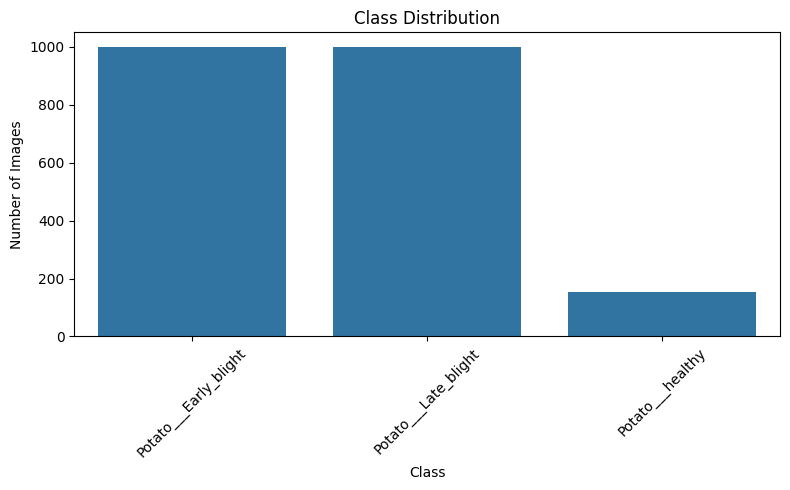

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Extract labels from dataset
class_names = dataset.class_names
label_counts = {name: 0 for name in class_names}

for _, labels in dataset:
    for label in labels.numpy():
        label_counts[class_names[label]] += 1

# Plot class distribution
plt.figure(figsize=(8, 5))
sns.barplot(x=list(label_counts.keys()), y=list(label_counts.values()))
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
from collections import Counter

shapes = [img.shape for img, _ in dataset]  # assuming a list of (image, label)
shape_counts = Counter(shapes)
print("Image shape distribution:", shape_counts)


Image shape distribution: Counter({TensorShape([32, 256, 256, 3]): 67, TensorShape([8, 256, 256, 3]): 1})


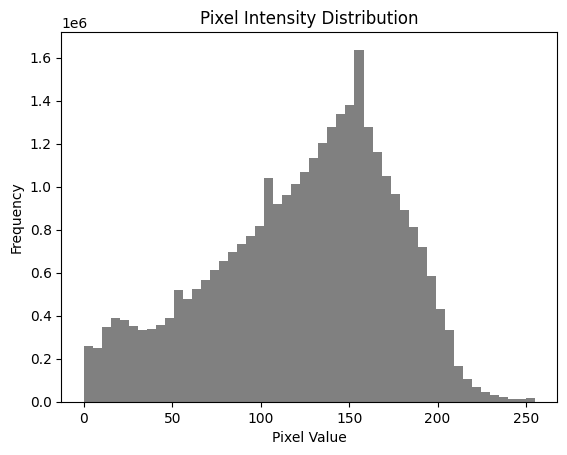

In [ ]:
all_pixels = []

for images, _ in dataset.take(5):  # just a few batches to keep memory use low
    all_pixels.append(images.numpy().flatten())

import numpy as np
pixel_values = np.concatenate(all_pixels)

plt.hist(pixel_values, bins=50, color='gray')
plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()


We used exploratory data analysis (EDA) to understand and prepare the dataset for our CNN model. All images were 256×256 pixels with 3 color channels (RGB), which ensures consistency and compatibility with the CNN input requirements. The image shape distribution confirmed that the dataset is clean and uniformly processed. The pixel intensity distribution showed that most values range between 80 and 180, with a peak around 150. This means the images have good contrast and lighting, which helps the model learn useful features. These pixel variations suggest that the images contain meaningful patterns, such as color and texture differences, which CNNs are very good at recognizing. Based on this, a CNN is a suitable and effective model for our image classification task.

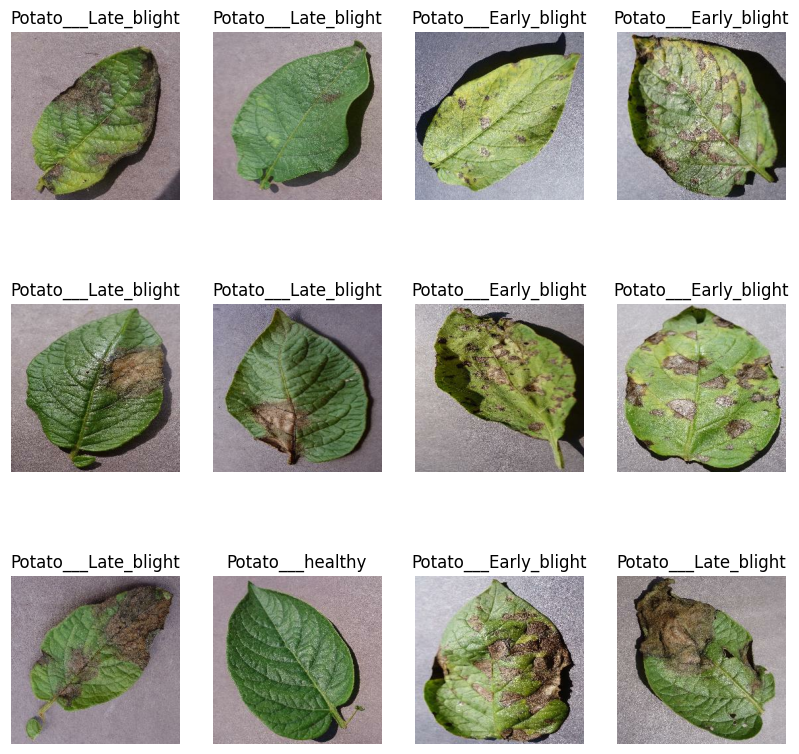

In [ ]:
plt.figure(figsize=(10,10)) #increased the dimensions
for image_batch, label_batch in dataset.take(1):
    #print(image_batch.shape)
    #print(label_batch.numpy())
    #print(image_batch[0].numpy)

    #print the 3D arrey of i images
    for i in range(12):
        ax = plt.subplot(3, 4, i+1)  # Used 3*4 matrix subplot
        plt.imshow(image_batch[i].numpy().astype("uint8"))  # Convert float to int
        plt.title(class_names[label_batch[i]])  # Supply class name as an index
        plt.axis("off")  # Hide axis


# Pre-processing

## Test- Train- Validation Split

In [ ]:
len(dataset)

68

In [ ]:
# 80% ==> training
# 20% ==> 10% validation, 10% test
train_size = 0.8
len(dataset)*train_size #calculate the num of baches for training dataset

54.400000000000006

In [ ]:
train_ds = dataset.take(54)# so 1st 54 batches of data set will be our training dataset
len(train_ds)

54

In [ ]:
test_ds = dataset.skip(54)
len(test_ds)

14

In [ ]:
val_size = 0.1
len(dataset)*val_size #calculate the num of baches for test dataset

6.800000000000001

In [ ]:
val_ds = test_ds.take(6)
len(val_ds) # so 1st 6 batches of test data set will be our validation dataset

6

In [ ]:
test_ds = test_ds.skip(6)
len(test_ds)

8

In [ ]:
def get_dataset_partitions_tf(ds,train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size=10000):

    # Get the total size of the dataset.
    ds_size = len(ds)

    if shuffle:
        # Shuffle the dataset to ensure randomness in the splits.
        ds = ds.shuffle(shuffle_size, seed=12)
    # Calculate the sizes of the training, validation, and test datasets.
    train_size = int(train_split * ds_size)
    val_size = int(val_split * ds_size)

    # Split the dataset into training, validation, and test sets.
    train_ds = ds.take(train_size)  # Take the first 'train_size' samples for training.
    val_ds = ds.skip(train_size).take(val_size)  # Skip the training samples and take 'val_size' samples for validation.
    test_ds = ds.skip(train_size).skip(val_size)  # Skip training and validation samples, use the rest for testing.

    return train_ds, val_ds, test_ds

In [ ]:
len(train_ds)# train size

54

In [ ]:
len(val_ds)# validation size

6

In [ ]:
len(test_ds)# test size

8

## Noramalization and augmentation

In [ ]:
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)  # Cache, shuffle, and prefetch training data
val_ds = val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)  # Cache, shuffle, and prefetch validation data
test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)  # Cache, shuffle, and prefetch test data


In [ ]:
resize_and_rescale = tf.keras.Sequential([
    tf.keras.layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),  # Resize images to fixed size
   tf.keras.layers.Rescaling(1.0/255)  # Normalize pixel values to [0, 1]
])


In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),  # Randomly flip images both horizontally and vertically
    tf.keras.layers.RandomRotation(0.2)  # Randomly rotate images by up to 20%
])



# Build and Train the CNN Model

In [ ]:
# Use convolutional neural network to train the model (trial and error approach)
input_shape = (BATCH_SIZE, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)  # Define input shape
n_classes = 3  # Number of output classes

model = models.Sequential([
    resize_and_rescale,  # Resize and normalize images
    data_augmentation,  # Apply random augmentations

    layers.Conv2D(32, (3,3), activation='relu', input_shape=input_shape),  # First conv layer (trial and error)
    layers.MaxPooling2D((2,2)),  # First pooling layer

    layers.Conv2D(64, (3,3), activation='relu'),  # Second conv layer (experimenting)
    layers.MaxPooling2D((2,2)),  # Second pooling layer

    layers.Conv2D(64, (3,3), activation='relu'),  # Third conv layer (adjusting depth)
    layers.MaxPooling2D((2,2)),  # Third pooling layer

    layers.Conv2D(64, (3,3), activation='relu'),  # Fourth conv layer (testing deeper network)
    layers.MaxPooling2D((2,2)),  # Fourth pooling layer

    layers.Conv2D(64, (3,3), activation='relu'),  # Fifth conv layer (fine-tuning)
    layers.MaxPooling2D((2,2)),  # Fifth pooling layer

    layers.Conv2D(64, (3,3), activation='relu'),  # Sixth conv layer (trial and error)
    layers.MaxPooling2D((2,2)),  # Sixth pooling layer

    layers.Flatten(),  # Flatten feature maps
    layers.Dense(64, activation='relu'),  # Fully connected layer (experimenting with 64 neurons)
    layers.Dense(n_classes, activation='softmax'),  # Output layer with softmax activation
])

model.build(input_shape=input_shape)  # Build model based on input shape


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_3 (Sequential)       │ (32, 256, 256, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_4 (Sequential)       │ (32, 256, 256, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (32, 254, 254, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (32, 127, 127, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (32, 125, 125, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (32, 62, 62, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (32, 60, 60, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (32, 30, 30, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (32, 28, 28, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (32, 14, 14, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (32, 12, 12, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (32, 6, 6, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (32, 4, 4, 64)         │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (32, 2, 2, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (32, 256)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (32, 64)               │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (32, 3)                │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 183,747 (717.76 KB)

 Trainable params: 183,747 (717.76 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile the model with the following configurations:
model.compile(
    # Optimizer used for training the model; 'adam' adapts the learning rate during training
    optimizer='adam',

    # Loss function used to measure the error during training; SparseCategoricalCrossentropy is used for multi-class classification problems with integer labels.
    # The 'from_logits=False' parameter indicates that the output layer's activation function (like softmax) is already applied.
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),

    # Metrics used to evaluate the model's performance; 'accuracy' measures the proportion of correct predictions.
    metrics=['accuracy']
)


In [ ]:
history = model.fit(
    train_ds,              # The training data (features and labels)
    epochs=EPOCHS,         # Number of times to loop through the whole training data
    batch_size=BATCH_SIZE, # Number of samples in each group (batch) during training
    verbose=1,             # Show progress during training
    validation_data=val_ds # Data used to check the model's performance after each training cycle
)


Epoch 1/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 19s 145ms/step - accuracy: 0.4925 - loss: 0.9393 - val_accuracy: 0.4688 - val_loss: 0.9138
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.5186 - loss: 0.8830 - val_accuracy: 0.8073 - val_loss: 0.5255
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.7292 - loss: 0.6260 - val_accuracy: 0.8542 - val_loss: 0.3344
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.7785 - loss: 0.5201 - val_accuracy: 0.8750 - val_loss: 0.2935
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.8841 - loss: 0.3040 - val_accuracy: 0.9115 - val_loss: 0.2137
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step - accuracy: 0.9068 - loss: 0.2450 - val_accuracy: 0.9219 - val_loss: 0.1707
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.9193 - loss: 0.2108 - val_accuracy: 0.9323 - val_loss: 0.1522
Epoch 8/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.9319 - loss: 0.1656 - val_accuracy: 0.9427 -

## Modal Summary

In [ ]:
history

In [ ]:
history.params

{'verbose': 1, 'epochs': 50, 'steps': 54}

In [ ]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [ ]:
acc = history.history['accuracy']         # Get the accuracy values from the training process
val_acc = history.history['val_accuracy'] # Get the validation accuracy values from the training process

loss = history.history['loss']            # Get the loss values from the training process
val_loss = history.history['val_loss']    # Get the validation loss values from the training process


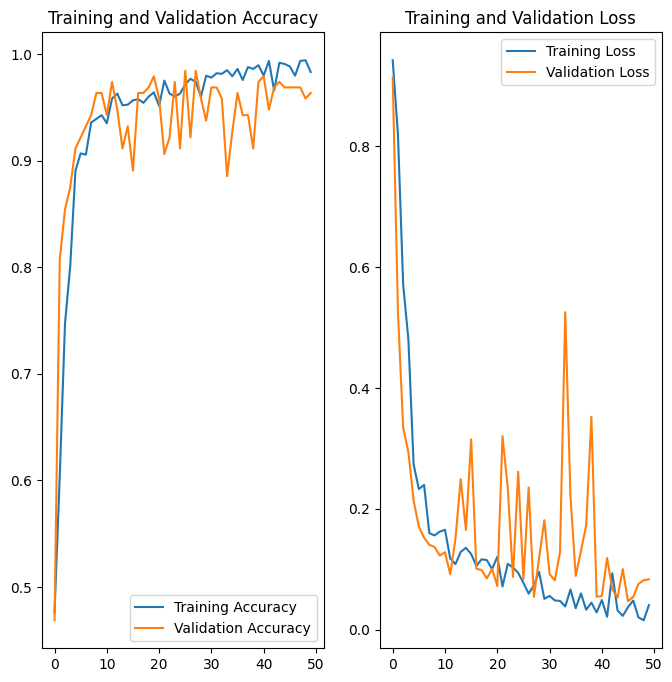

In [ ]:
plt.figure(figsize=(8,8))  # Create a figure with a size of 8x8 inches

plt.subplot(1, 2, 1)  # Create the first subplot (1 row, 2 columns, this is the first subplot)
plt.plot(range(EPOCHS), acc, label='Training Accuracy')  # Plot the training accuracy vs. epoch
plt.plot(range(EPOCHS), val_acc, label='Validation Accuracy')  # Plot the validation accuracy vs. epoch
plt.legend(loc='lower right')  # Add a legend in the lower right corner
plt.title('Training and Validation Accuracy')  # Set the title for this subplot

plt.subplot(1, 2, 2)  # Create the second subplot (1 row, 2 columns, this is the second subplot)
plt.plot(range(EPOCHS), loss, label='Training Loss')  # Plot the training loss vs. epoch
plt.plot(range(EPOCHS), val_loss, label='Validation Loss')  # Plot the validation loss vs. epoch
plt.legend(loc='upper right')  # Add a legend in the upper right corner
plt.title('Training and Validation Loss')  # Set the title for this subplot

plt.show()  # Show the plots


In [ ]:
np.argmax([9.9999964e-01, 3.9333537e-07, 1.1586251e-18]) # Find the index of the largest value.Output: 0 (since the largest value is at index 0)

np.int64(0)

## Testing and evaluvation matrices

In [ ]:
# Evaluate model on test dataset
test_loss, test_accuracy = model.evaluate(test_ds)
print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)


8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - accuracy: 0.9548 - loss: 0.1231
Test Accuracy: 0.9568965435028076
Test Loss: 0.14157438278198242


In [ ]:
import numpy as np

y_pred = []
y_true = []

for images, labels in test_ds:
    preds = model.predict(images)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

y_pred = np.array(y_pred)
y_true = np.array(y_true)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


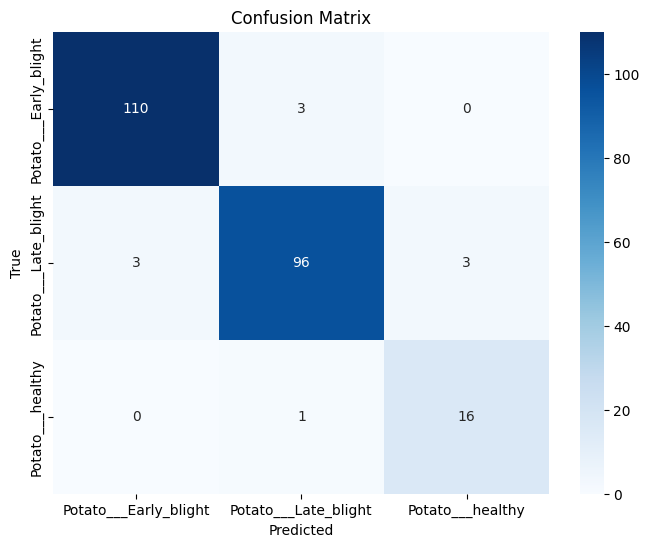

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
from sklearn.metrics import classification_report

report = classification_report(y_true, y_pred, target_names=class_names)
print(report)


                       precision    recall  f1-score   support

Potato___Early_blight       0.97      0.97      0.97       113
 Potato___Late_blight       0.96      0.94      0.95       102
     Potato___healthy       0.84      0.94      0.89        17

             accuracy                           0.96       232
            macro avg       0.93      0.95      0.94       232
         weighted avg       0.96      0.96      0.96       232



The classification model for detecting potato plant diseases has performed very well, achieving an overall accuracy of 96%. The confusion matrix shows that most images were correctly classified, with only a few misclassifications. Early blight and late blight were identified with high precision and recall, while the healthy class, although smaller in number, also showed strong results. The precision for the healthy class was slightly lower, likely due to the limited number of samples. Overall, the model demonstrates reliable and accurate performance in distinguishing between the three classes of potato plant conditions.

## Modal Exporting

In [ ]:
#import os

#model_version = max([int(i) for i in os.listdir("../saved_models")] + [0]) + 1  # Get the next model version number
#model.export(f"../saved_models/{model_version}")  # Export the model to the new versioned directory
#tf.keras.models.save_model(model,f"../saved_models/{model_version}.keras")
import os
import tensorflow as tf  # ensure TensorFlow is imported

# Gather numeric version numbers from files in the saved_models directory
versions = []
for filename in os.listdir("../saved_models"):
    base, ext = os.path.splitext(filename)
    if base.isdigit():
        versions.append(int(base))

# Determine the next version number
model_version = max(versions, default=0) + 1

tf.keras.models.save_model(model, f"../saved_models/{model_version}.keras")
